## Basic EDA (Assignment 1)

This notebook does a quick, lightweight exploration of the Kaggle **Jigsaw Toxic Comment Classification** dataset.

**Expected files** (place in repo root or `./data/`):
- `train.csv`
- `test.csv`


In [6]:
from pathlib import Path

import pandas as pd
import numpy as np

# Optional plotting (the notebook still works without it)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOTS = True
except Exception:
    HAS_PLOTS = False

LABEL_COLS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
]

repo_root = Path.cwd()
train_path = next((p for p in [repo_root/"train.csv", repo_root/"data"/"train.csv"] if p.exists()), None)
test_path  = next((p for p in [repo_root/"test.csv",  repo_root/"data"/"test.csv"]  if p.exists()), None)

train_path, test_path

(WindowsPath('e:/Projects/ToxicCommentClassification/train.csv'),
 WindowsPath('e:/Projects/ToxicCommentClassification/test.csv'))

In [7]:
if train_path is None or test_path is None:
    missing = []
    if train_path is None:
        missing.append("train.csv")
    if test_path is None:
        missing.append("test.csv")
    print(
        f"Missing {', '.join(missing)}.\n"
        "Download from Kaggle and place in the repo root or ./data/, then rerun the notebook."
    )
else:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    print("train shape:", train_df.shape)
    print("test  shape:", test_df.shape)
    display(train_df.head(3))

train shape: (159571, 8)
test  shape: (153164, 2)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


In [8]:
if "train_df" not in globals() or "test_df" not in globals():
    print("Load train/test first (run the previous cell).")
else:
    print("Train columns:")
    print(train_df.columns.tolist())

    print("\nMissing values (train):")
    miss = train_df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0]
    display(miss if len(miss) else "(none)")

    print("\nMissing values (test):")
    miss_t = test_df.isna().sum().sort_values(ascending=False)
    miss_t = miss_t[miss_t > 0]
    display(miss_t if len(miss_t) else "(none)")

Train columns:
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Missing values (train):


'(none)'


Missing values (test):


'(none)'

,positives,positive_rate
toxic,15294,0.095844
obscene,8449,0.052948
insult,7877,0.049364
severe_toxic,1595,0.009996
identity_hate,1405,0.008805
threat,478,0.002996


Any-toxic rate: 0.1017


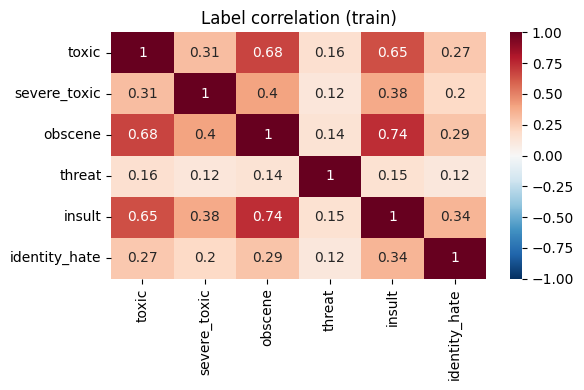

In [9]:
if "train_df" not in globals():
    print("Load train/test first (run the previous cell).")
else:
    present_labels = [c for c in LABEL_COLS if c in train_df.columns]
    if not present_labels:
        print("No label columns found. Expected:", LABEL_COLS)
    else:
        y = train_df[present_labels].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        y = (y > 0).astype(int)

        label_balance = pd.DataFrame({
            "positives": y.sum(axis=0),
            "positive_rate": y.mean(axis=0),
        }).sort_values("positive_rate", ascending=False)

        any_toxic = (y.sum(axis=1) > 0).mean()

        display(label_balance)
        print(f"Any-toxic rate: {any_toxic:.4f}")

        # quick co-occurrence correlation
        if HAS_PLOTS:
            plt.figure(figsize=(6, 4))
            sns.heatmap(y.corr(), annot=True, cmap="RdBu_r", vmin=-1, vmax=1)
            plt.title("Label correlation (train)")
            plt.tight_layout()
            plt.show()

chars_mean    394.07
chars_p50     205.00
chars_p90     889.00
words_mean     67.27
words_p50      36.00
words_p90     152.00
dtype: float64

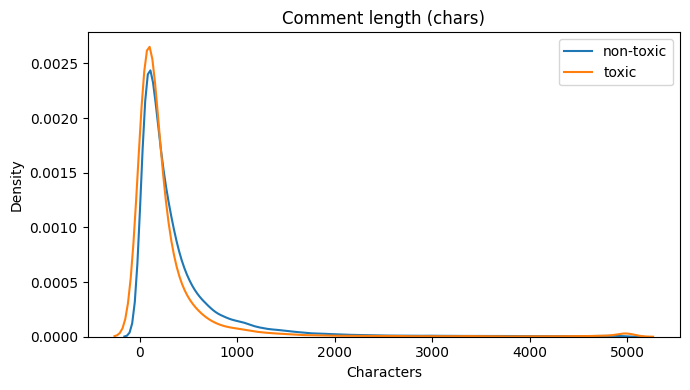

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
131181,bde12bf272afe2d2,"""==Nagisa Oshima TV documentaries==\nHi, I thi...",0,0,0,0,0,0
48432,8177cd93538cc152,"""\nSame here, he he I did not notice. Thank y...",0,0,0,0,0,0
64229,abdfcf4e47023e9b,Why because there was an attack on this articl...,0,0,0,0,0,0
96024,01942be64014da76,Mike Reiss==\n\nMike Reiss actually makes the ...,0,0,0,0,0,0
70553,bccc084b0deb11c0,this article could do with being tidied up by ...,0,0,0,0,0,0


In [10]:
if "train_df" not in globals():
    print("Load train/test first (run the previous cell).")
else:
    TEXT_COL = "comment_text"
    if TEXT_COL not in train_df.columns:
        print(f"No text column `{TEXT_COL}` found.")
    else:
        s = train_df[TEXT_COL].fillna("").astype(str)
        char_len = s.str.len()
        word_len = s.str.split().map(len)

        stats = pd.Series({
            "chars_mean": char_len.mean(),
            "chars_p50": char_len.quantile(0.50),
            "chars_p90": char_len.quantile(0.90),
            "words_mean": word_len.mean(),
            "words_p50": word_len.quantile(0.50),
            "words_p90": word_len.quantile(0.90),
        })
        display(stats.round(2))

        if HAS_PLOTS and "y" in globals():
            any_toxic_mask = (y.sum(axis=1) > 0)
            plt.figure(figsize=(7, 4))
            sns.kdeplot(x=char_len[~any_toxic_mask], label="non-toxic")
            sns.kdeplot(x=char_len[any_toxic_mask], label="toxic")
            plt.title("Comment length (chars)")
            plt.xlabel("Characters")
            plt.legend()
            plt.tight_layout()
            plt.show()

        present_labels = [c for c in LABEL_COLS if c in train_df.columns]
        cols = ["id", TEXT_COL] + present_labels
        display(train_df[cols].sample(5, random_state=7))